In [1]:
import pandas as pd
import plotly.express as px

file_path = '../data/clean/BornesPropres_with_depart_v2.csv'
df = pd.read_csv(file_path)

print(df.columns)

/tmp/ipykernel_27272/3081131492.py:5: DtypeWarning: Columns (15,16,17,18,19,20,21,26,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Index(['nom_amenageur', 'contact_amenageur', 'nom_operateur',
       'contact_operateur', 'nom_enseigne', 'id_station_itinerance',
       'id_station_local', 'nom_station', 'implantation_station',
       'adresse_station', 'coordonneesXY', 'nbre_pdc', 'id_pdc_itinerance',
       'id_pdc_local', 'puissance_nominale', 'prise_type_ef', 'prise_type_2',
       'prise_type_combo_ccs', 'prise_type_chademo', 'prise_type_autre',
       'gratuit', 'paiement_acte', 'paiement_cb', 'paiement_autre',
       'tarification', 'condition_acces', 'reservation', 'horaires',
       'accessibilite_pmr', 'restriction_gabarit', 'station_deux_roues',
       'raccordement', 'date_mise_en_service', 'date_maj', 'cable_t2_attache',
       'last_modified', 'datagouv_dataset_id', 'datagouv_resource_id',
       'datagouv_organization_or_owner', 'created_at',
       'consolidated_longitude', 'consolidated_latitude',
       'consolidated_is_lon_lat_correct',
       'consolidated_is_code_insee_verified',
       'consoli

In [4]:
file_path_TMJA = '../data/raw/TMJA2016_2019_Propre.csv'
df_TMJA = pd.read_csv(file_path_TMJA)

print(df_TMJA.columns)

Index(['objetID', 'route', 'longueur', 'depPrD', 'xD', 'yD', 'zD', 'depPrF',
       'xF', 'yF', 'zF', 'anneeMesureTrafic', 'TMJA', 'geopoint_depart',
       'geopoint_fin', 'TMJA_avg', 'TMJA_actualise', 'count'],
      dtype='object')


/tmp/ipykernel_27272/3698733742.py:7: DtypeWarning: Columns (15,16,17,18,19,20,21,26,30) have mixed types. Specify dtype option on import or set low_memory=False.
  bornes = pd.read_csv("../data/clean/BornesPropres_with_depart_v2.csv")


Nombre de départements communs : 85


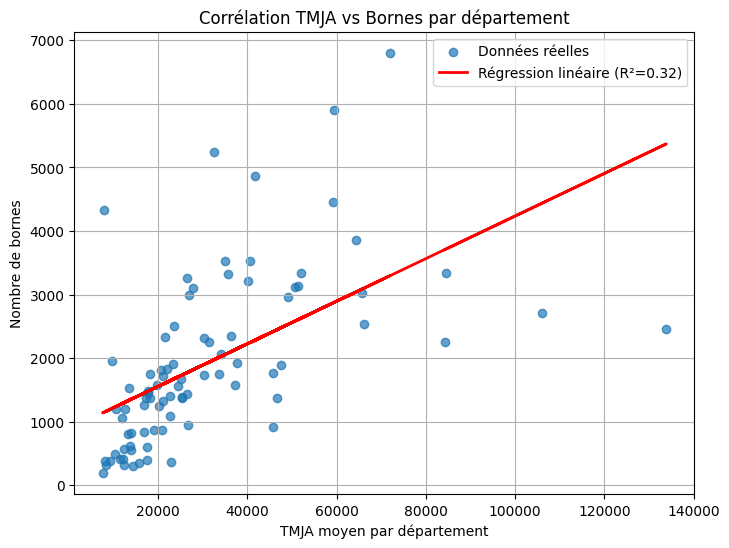

Coefficient de corrélation (Pearson) : 0.564


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# --- 1. Charger les fichiers ---
bornes = pd.read_csv("../data/clean/BornesPropres_with_depart_v2.csv")
tmja = pd.read_csv("../data/raw/TMJA2016_2019_Propre.csv")

# --- 2. Nettoyage num_departement ---
bornes = bornes.dropna(subset=["num_departement"])
bornes["num_departement"] = (
    bornes["num_departement"]
    .astype(float)
    .astype(int)
    .astype(str)
    .str.zfill(2)
)

# --- 3. Nettoyage depPrD ---
tmja["depPrD"] = tmja["depPrD"].astype(int).astype(str).str.zfill(2)

# --- 4. Agrégation ---
bornes_dept = bornes.groupby("num_departement").size().reset_index(name="bornes_count")
tmja_dept = tmja.groupby("depPrD")["TMJA_actualise"].mean().reset_index()

# --- 5. Fusion ---
df_merge = pd.merge(
    bornes_dept,
    tmja_dept,
    left_on="num_departement",
    right_on="depPrD",
    how="inner"
)

print(f"Nombre de départements communs : {df_merge.shape[0]}")

# --- 6. Modèle de régression linéaire ---
X = df_merge["TMJA_actualise"].values.reshape(-1, 1)
y = df_merge["bornes_count"].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Coefficient R²
r2 = model.score(X, y)

# --- 7. Graphique ---
plt.figure(figsize=(8,6))
plt.scatter(X, y, alpha=0.7, label="Données réelles")
plt.plot(X, y_pred, color="red", linewidth=2, label=f"Régression linéaire (R²={r2:.2f})")
plt.xlabel("TMJA moyen par département")
plt.ylabel("Nombre de bornes")
plt.title("Corrélation TMJA vs Bornes par département")
plt.grid(True)
plt.legend()
plt.show()

# --- 8. Corrélation de Pearson ---
corr = df_merge["TMJA_actualise"].corr(df_merge["bornes_count"])
print(f"Coefficient de corrélation (Pearson) : {corr:.3f}")
